# Attention-LSTM Model

### SETUP

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

PROCESSED_PATH = r'../../processed_data'
MODEL_SAVE_PATH = r'./model_checkpoints'

if not os.path.exists(MODEL_SAVE_PATH):
    os.makedirs(MODEL_SAVE_PATH)

### LOAD PROCESSED DATA AND DEFINING ATTENTION LAYER

In [7]:
X_train = np.load(os.path.join(PROCESSED_PATH, 'X_train_FD001.npy'))
y_train = np.load(os.path.join(PROCESSED_PATH, 'y_train_FD001.npy'))
X_test = np.load(os.path.join(PROCESSED_PATH, 'X_test_FD001.npy'))
y_test = np.load(os.path.join(PROCESSED_PATH, 'y_test_FD001.npy'))

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")


class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        # The attention weights: (Features, 1)
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # x shape: (batch_size, time_steps, features)
        # e = tanh(dot(x, W) + b)
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        
        # alpha = softmax(e)
        a = tf.keras.backend.softmax(e, axis=1)
        
        output = x * a
        
        # Sum over time steps to get context vector
        return tf.keras.backend.sum(output, axis=1)

X_train Shape: (17631, 30, 15)
y_train Shape: (17631,)


### BUILDING MODEL

In [8]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # LSTM Layer: Returns full sequence for Attention
    x = LSTM(128, return_sequences=True, name='lstm_layer')(inputs)
    x = Dropout(0.3)(x) # Prevent overfitting
    
    # Attention Layer: Focuses on important time steps
    x = Attention(name='attention_layer')(x)
    
    # Fully Connected Layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x) # Higher dropout to prevent overfitting
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    
    # Output Layer (Linear for Regression)
    outputs = Dense(1, activation='linear')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Input shape is (30, 15)
model = build_model((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()   

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)               ┃ Output Shape        ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer) │ (None, 30, 15)      │           0 │
├────────────────────────────┼─────────────────────┼─────────────┤
│ lstm_layer (LSTM)          │ (None, 30, 128)     │      73,728 │
├────────────────────────────┼─────────────────────┼─────────────┤
│ dropout_2 (Dropout)        │ (None, 30, 128)     │           0 │
├────────────────────────────┼─────────────────────┼─────────────┤
│ attention_layer            │ (None, 128)         │         158 │
│ (Attention)                │                     │             │
├────────────────────────────┼─────────────────────┼─────────────┤
│ dense_3 (Dense)            │ (None, 128)         │      16,512 │
├────────────────────────────┼─────────────────────┼─────────────┤
│ dropout_3 (Dropout)        │ (None, 128)         │           0 │
├────────────────────────────┼─────────────────────┼─────────────┤
│ dense_4 (Dense)            │ (None, 64)          │       8,256 │
├────────────────────────────┼─────────────────────┼─────────────┤
│ dropout_4 (Dropout)        │ (None, 64)          │           0 │
├────────────────────────────┼─────────────────────┼─────────────┤
│ dense_5 (Dense)            │ (None, 1)           │          65 │
└────────────────────────────┴─────────────────────┴─────────────┘

 Total params: 98,719 (385.62 KB)

 Trainable params: 98,719 (385.62 KB)

 Non-trainable params: 0 (0.00 B)

### TRAINING MODEL

In [10]:
# Callbacks to stop early if we stop improving
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,           # Max epochs (will stop early)
    batch_size=200,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 5317.3223 - mae: 61.2184 - val_loss: 1719.7301 - val_mae: 36.8018 - learning_rate: 0.0010
Epoch 2/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 1834.9669 - mae: 36.7626 - val_loss: 1161.4563 - val_mae: 27.0435 - learning_rate: 0.0010
Epoch 3/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 1012.6706 - mae: 25.5027 - val_loss: 896.4910 - val_mae: 22.5916 - learning_rate: 0.0010
Epoch 4/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 867.9375 - mae: 23.4130 - val_loss: 748.5114 - val_mae: 22.2088 - learning_rate: 0.0010
Epoch 5/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 717.8423 - mae: 21.1466 - val_loss: 435.8995 - val_mae: 16.5727 - learning_rate: 0.0010
Epoch 6/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 588.2015 - mae: 18.7351 - val_loss: 318.4181 - val_mae: 13.9430 - learning_rate: 0.0010
Epoch 7/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 534.3345 - mae: 17.6375 - val_loss: 527.5209 - 

### EVALUATE & SAVE

In [12]:
print("\nResults: ")
predictions = model.predict(X_test)
rmse = np.sqrt(np.mean((predictions.flatten() - y_test) ** 2))
print(f"Test RMSE: {rmse:.4f}")

if rmse < 15.0:
    print("SUCCESS: Benchmark (RMSE < 15) Achieved!")
else:
    print("Optimization Needed: Tune hyperparameters.")


Results: 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Test RMSE: 14.6955
SUCCESS: Benchmark (RMSE < 15) Achieved!


  ### SAVING MODEL

In [13]:
model.save(os.path.join(MODEL_SAVE_PATH, 'attention_lstm_fd001.h5'))
print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to ./model_checkpoints


### PLOTTING LOSS CURVES AND PREDICTIONS VS TRUE RUL

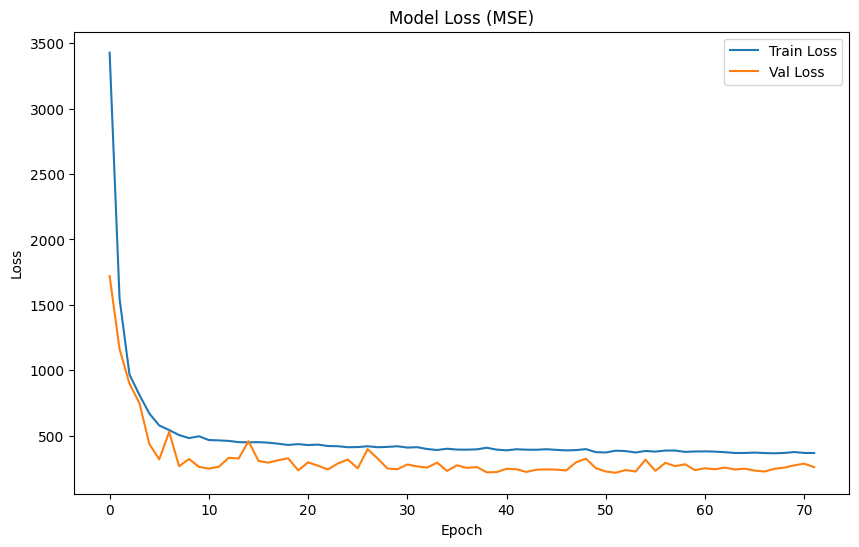

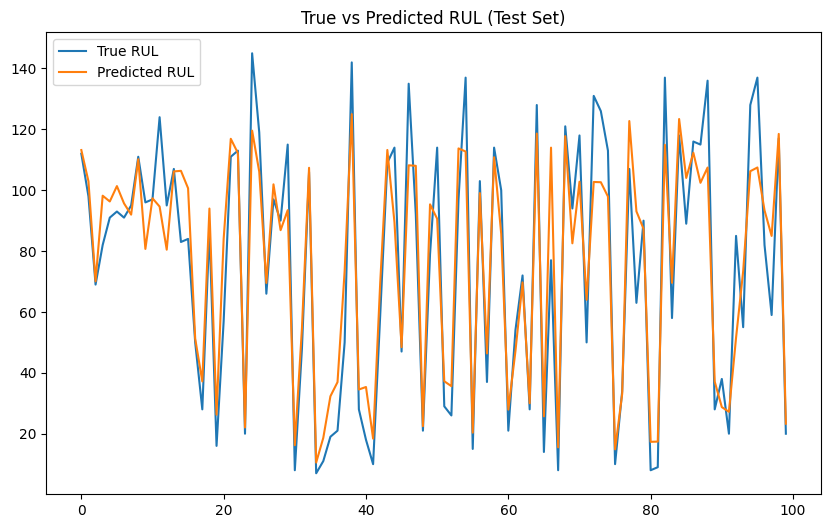

In [14]:
# Plot Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot Predictions vs True RUL
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True RUL')
plt.plot(predictions, label='Predicted RUL')
plt.title('True vs Predicted RUL (Test Set)')
plt.legend()
plt.show()

### VISUALIZATIONS

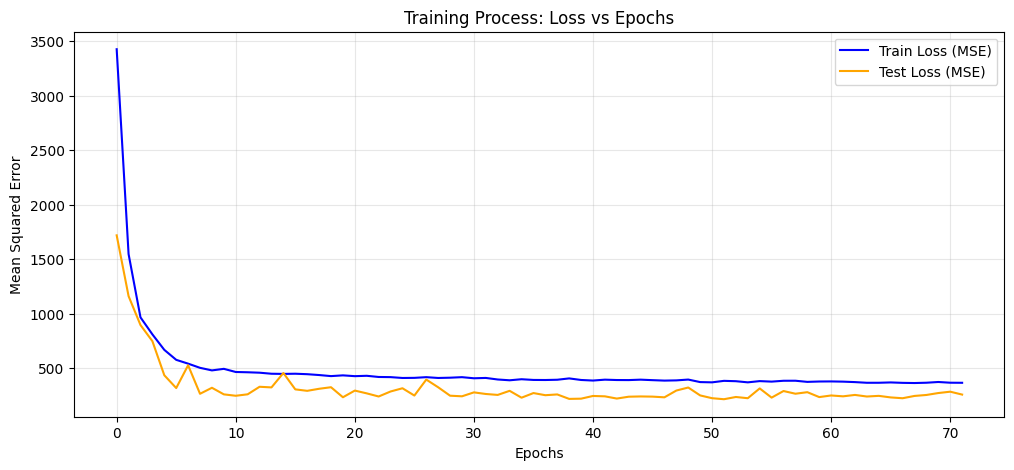

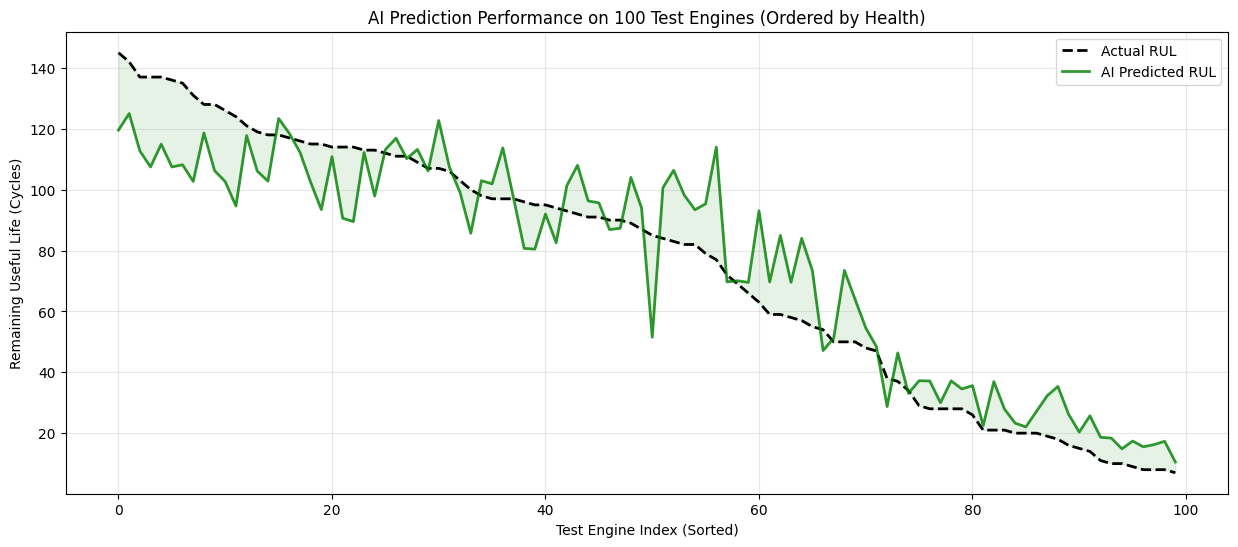

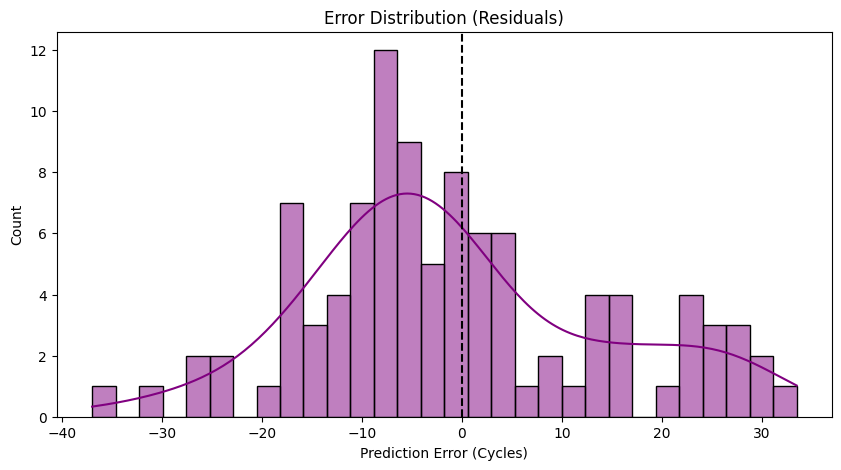

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Loss Curves 
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Test Loss (MSE)', color='orange')
plt.title('Training Process: Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Prediction vs True RUL 
results_df = pd.DataFrame({
    'True_RUL': y_test,
    'Pred_RUL': predictions.flatten()
})
results_df = results_df.sort_values(by='True_RUL', ascending=False).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.plot(results_df['True_RUL'], label='Actual RUL', color='black', linewidth=2, linestyle='--')
plt.plot(results_df['Pred_RUL'], label='AI Predicted RUL', color='green', linewidth=2, alpha=0.8)
plt.fill_between(results_df.index, results_df['True_RUL'], results_df['Pred_RUL'], color='green', alpha=0.1)

plt.title('AI Prediction Performance on 100 Test Engines (Ordered by Health)')
plt.xlabel('Test Engine Index (Sorted)')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Residual Distribution (Error Analysis)
residuals = results_df['True_RUL'] - results_df['Pred_RUL']
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title('Error Distribution (Residuals)')
plt.xlabel('Prediction Error (Cycles)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

### NASA SCORE AND CUSTOM ACCURACY 

In [19]:
import numpy as np

# --- 1. NASA SCORING FUNCTION ---
# This is the "Official" metric used in the PHM08 Challenge
# It penalizes LATE predictions (d > 0) more than EARLY predictions (d < 0)
# Because predicting "It's fine" when it's about to explode is dangerous!

def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = 0
    for error in d:
        if error < 0:
            # Early Prediction (Safe-ish)
            score += np.exp(-error/13) - 1
        else:
            # Late Prediction (Dangerous!)
            score += np.exp(error/10) - 1
    return score

# --- 2. CUSTOM ACCURACY ---
# "What % of our predictions are within +/- 15 cycles of the truth?"
def strict_accuracy(y_true, y_pred, tolerance=15):
    errors = np.abs(y_true - y_pred)
    correct_preds = np.sum(errors <= tolerance)
    return (correct_preds / len(y_true)) * 100

# Calculate
my_score = nasa_score(y_test, predictions.flatten())
my_acc = strict_accuracy(y_test, predictions.flatten(), tolerance=15)

print(f"Final RMSE: {rmse:.4f}")
print(f"NASA Score: {my_score:.4f} (Lower is better)")
print(f"Accuracy (within +/- 15 cycles): {my_acc:.2f}%")

Final RMSE: 14.6955
NASA Score: 307.5779 (Lower is better)
Accuracy (within +/- 15 cycles): 66.00%
